In [144]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud, STOPWORDS

In [145]:
PATH = "openfda_phase2_cleaned.csv"
df = pd.read_csv(PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (7566, 5)


,report_id,report_date,patient_age,patient_sex,reaction
0,10005176,2014-03-12,65.0,2.0,fall
1,10005176,2014-03-12,65.0,2.0,spinal compression fracture
2,10005176,2014-03-12,65.0,2.0,spinal fracture
3,10005176,2014-03-12,65.0,2.0,ventricular extrasystoles
4,10005176,2014-03-12,65.0,2.0,heart rate decreased


In [146]:

df["report_date"] = pd.to_datetime(df["report_date"], errors="coerce")
df["patient_age"] = pd.to_numeric(df["patient_age"], errors="coerce")

sex_map = {1: "Male", 2: "Female"}
df["patient_sex_label"] = df["patient_sex"].map(sex_map)

#Age groups
df["age_group"] = pd.cut(
    df["patient_age"],
    bins=[0, 18, 40, 65, 120],
    labels=["0-17", "18-40", "41-65", "65+"]
)

In [147]:
print("\nDescriptive statistics:")
display(df.describe(include="all"))

print("\nUnique counts:")
print("\nUnique report_id:", df["report_id"].nunique())
print("Unique reactions:", df["reaction"].nunique())

print("\nTop reactions coverage (top 10 %):")
top10 = df["reaction"].value_counts().head(10)
top10_share = top10.sum() / len(df) * 100
print(top10)
print("Top 10 reactions share of all rows:", round(top10_share, 2), "%")


Descriptive statistics:


,report_id,report_date,patient_age,patient_sex,reaction,patient_sex_label,age_group
count,7.566000e+03,7566,6172.000000,7179.000000,7566,7179,6136
unique,NaN,NaN,NaN,NaN,1753,2,4
top,NaN,NaN,NaN,NaN,malaise,Female,41-65
freq,NaN,NaN,NaN,NaN,111,5077,3068
mean,1.202286e+07,2016-01-29 09:44:17.890562816,56.782890,1.707202,NaN,NaN,NaN
min,1.000518e+07,2014-03-06 00:00:00,0.000000,1.000000,NaN,NaN,NaN
25%,1.084397e+07,2015-02-20 00:00:00,49.000000,1.000000,NaN,NaN,NaN
50%,1.198166e+07,2016-01-31 00:00:00,61.000000,2.000000,NaN,NaN,NaN
75%,1.311884e+07,2017-01-16 00:00:00,69.000000,2.000000,NaN,NaN,NaN
max,1.418402e+07,2017-11-13 00:00:00,100.000000,2.000000,NaN,NaN,NaN



Unique counts:

Unique report_id: 1000
Unique reactions: 1753

Top reactions coverage (top 10 %):
reaction
malaise            111
dyspnoea           110
fatigue            110
cough               97
pyrexia             95
influenza           91
nausea              89
headache            81
pneumonia           80
nasopharyngitis     76
Name: count, dtype: int64
Top 10 reactions share of all rows: 12.42 %



Missing summary:


,missing_count,missing_%
age_group,1430,18.90
patient_age,1394,18.42
patient_sex,387,5.11
reaction,0,0.00
report_date,0,0.00
report_id,0,0.00


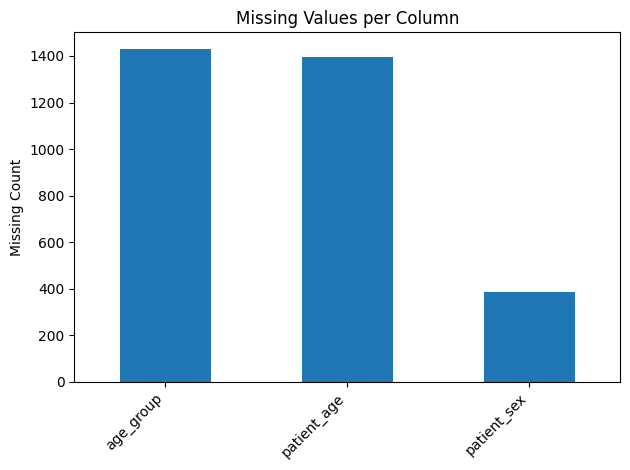

In [148]:
#Missing values
df_missing = df.drop(columns=["patient_sex_label"])#Exclude patient_sex_label since it is derived from patient_sex and has the same missing values
missing_count = df_missing.isna().sum().sort_values(ascending=False)
missing_pct = (df_missing.isna().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_%": missing_pct
})

print("\nMissing summary:")
display(missing_df)

missing_nonzero = missing_df[missing_df["missing_count"] > 0]

if len(missing_nonzero) > 0:
    missing_nonzero["missing_count"].plot(kind="bar")
    plt.title("Missing Values per Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Top 15 reactions:
reaction
malaise            111
dyspnoea           110
fatigue            110
cough               97
pyrexia             95
influenza           91
nausea              89
headache            81
pneumonia           80
nasopharyngitis     76
diarrhoea           72
pain                72
asthenia            66
arthralgia          64
vomiting            62
Name: count, dtype: int64


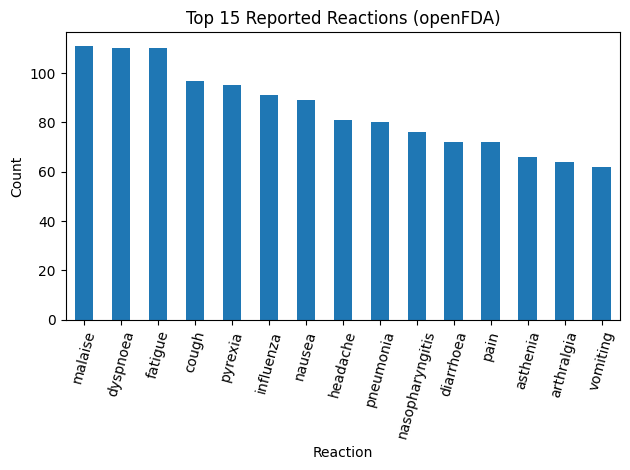

In [149]:
#Reaction frequency
top_reactions = df["reaction"].value_counts().head(15)
print("\nTop 15 reactions:")
print(top_reactions)

top_reactions.plot(kind="bar")
plt.title("Top 15 Reported Reactions (openFDA)")
plt.xlabel("Reaction")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()



Sex distribution:
patient_sex_label
Female     5077
Male       2102
Unknown     387
Name: count, dtype: int64


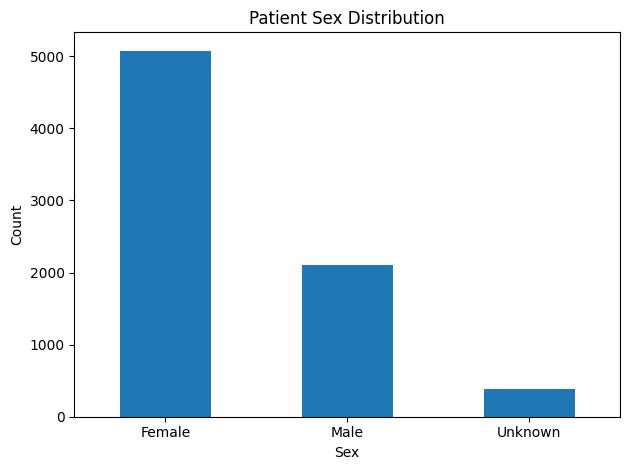

In [150]:
#Sex distribution
df["patient_sex_label"] = df["patient_sex_label"].fillna("Unknown")
sex_counts = df["patient_sex_label"].value_counts(dropna=False)
print("\nSex distribution:")
print(sex_counts)

sex_counts.plot(kind="bar")
plt.title("Patient Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Age describe:
count    6172.000000
mean       56.782890
std        18.315202
min         0.000000
25%        49.000000
50%        61.000000
75%        69.000000
max       100.000000
Name: patient_age, dtype: float64


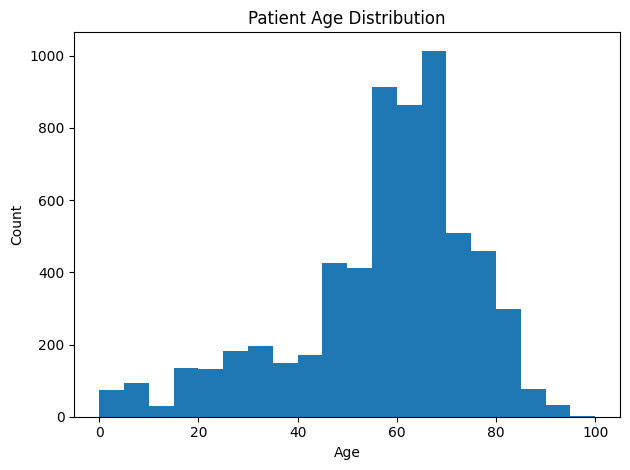

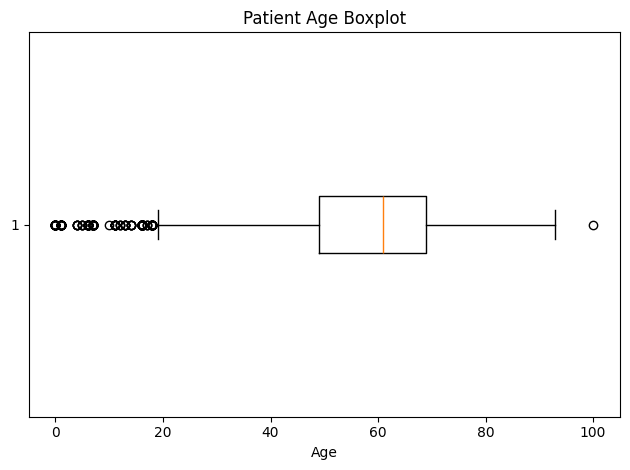

/tmp/ipykernel_218/2423732770.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Female", "Male"], vert=False)


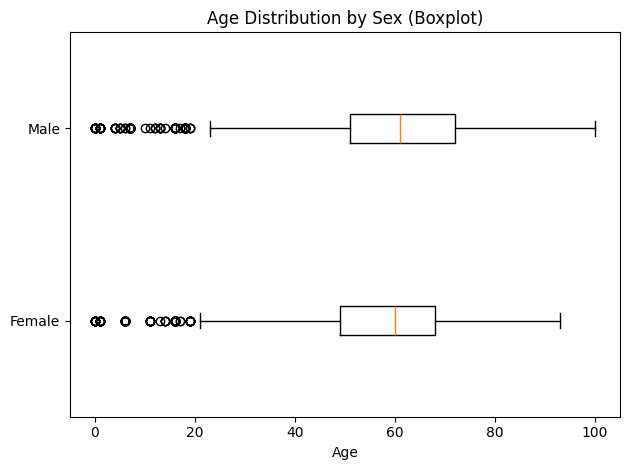

In [151]:
#Age distribution
age_series = df["patient_age"].dropna()

print("\nAge describe:")
print(age_series.describe())

plt.hist(age_series, bins=20)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.boxplot(age_series, vert=False)
plt.title("Patient Age Boxplot")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

#Age distribution by sex
df_age_sex = df.dropna(subset=["patient_age", "patient_sex_label"]).copy()
groups = [df_age_sex[df_age_sex["patient_sex_label"] == g]["patient_age"] for g in ["Female", "Male"] if g in df_age_sex["patient_sex_label"].unique()]

if len(groups) > 1:
    plt.boxplot(groups, labels=["Female", "Male"], vert=False)
    plt.title("Age Distribution by Sex (Boxplot)")
    plt.xlabel("Age")
    plt.tight_layout()
    plt.show()


Age group distribution:
age_group
41-65    3068
65+      2051
NaN      1430
18-40     733
0-17      284
Name: count, dtype: int64


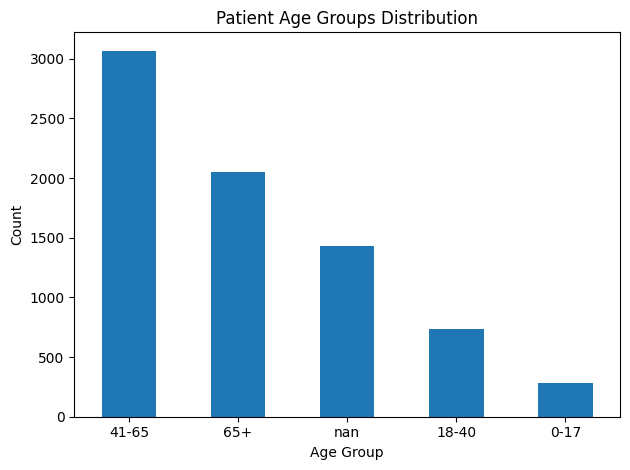

In [152]:
#Age group distribution
age_group_counts = df["age_group"].value_counts(dropna=False)
print("\nAge group distribution:")
print(age_group_counts)

age_group_counts.plot(kind="bar")
plt.title("Patient Age Groups Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Unique reports per month:
report_date
2014-03-31    28
2014-04-30    15
2014-05-31    22
2014-06-30    16
2014-07-31    18
Freq: ME, Name: report_id, dtype: int64


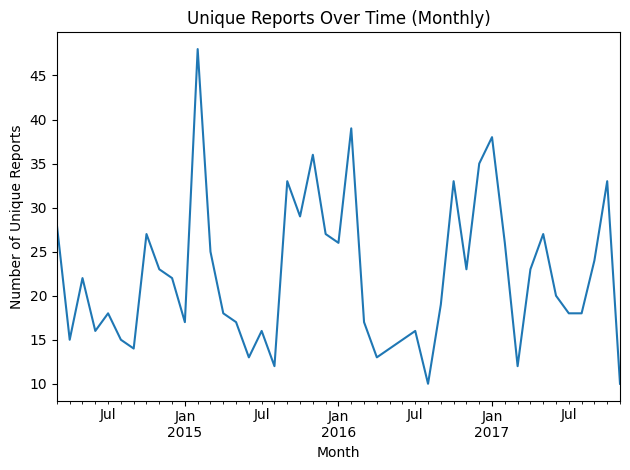

In [153]:
#Temporal trends: unique reports per month
reports_by_date = df.dropna(subset=["report_date"]).groupby("report_date")["report_id"].nunique()
reports_by_month = reports_by_date.resample("ME").sum()

print("\nUnique reports per month:")
print(reports_by_month.head())

reports_by_month.plot()
plt.title("Unique Reports Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Unique Reports")
plt.tight_layout()
plt.show()


Reactions per report describe:
count    1000.000000
mean        7.566000
std        11.066712
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       166.000000
Name: reaction, dtype: float64


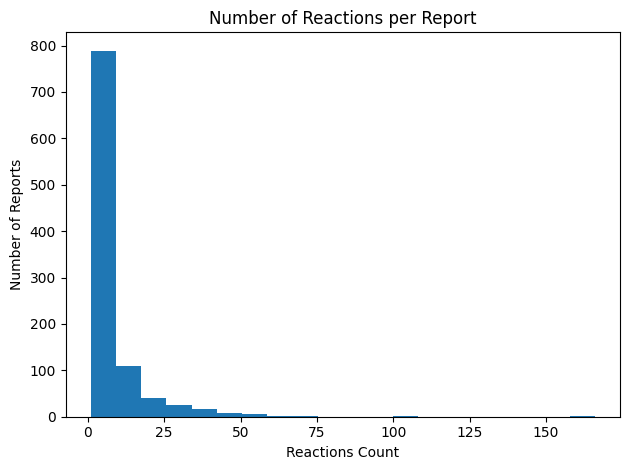

In [154]:
#Reactions per report
reactions_per_report = df.groupby("report_id")["reaction"].count()
print("\nReactions per report describe:")
print(reactions_per_report.describe())

plt.hist(reactions_per_report, bins=20)
plt.title("Number of Reactions per Report")
plt.xlabel("Reactions Count")
plt.ylabel("Number of Reports")
plt.tight_layout()
plt.show()

Most safety reports contain a small number of reactions, while a few reports include a large number of reactions. The distribution is right-skewed, with an average of approximately 7.6 reactions per report and a median of 4.

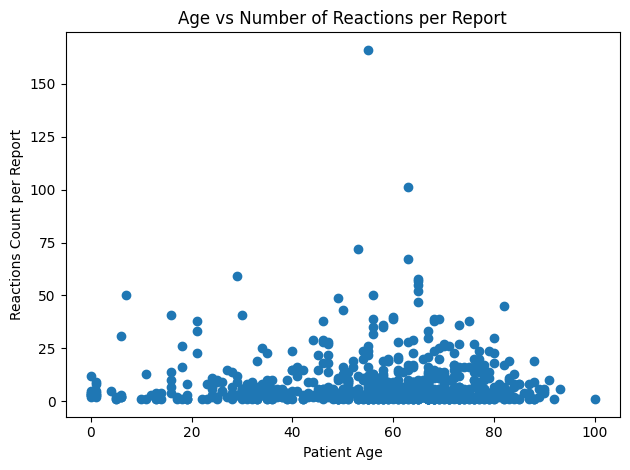


Correlation (Age vs reactions_count):
Pearson: -0.0022
Spearman: -0.0135


/tmp/ipykernel_218/3959048074.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_counts, male_counts], labels=["Female", "Male"], vert=False)


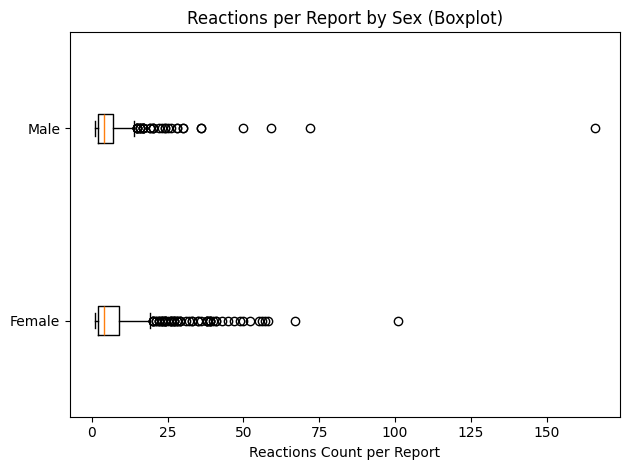

In [155]:
#Bivariate: Age vs reactions_per_repor
#Build report-level table: one row per report_id
report_level = (
    df.groupby("report_id")
      .agg(
          reactions_count=("reaction", "count"),
          report_date=("report_date", "min"),
          patient_age=("patient_age", "first"),
          patient_sex_label=("patient_sex_label", "first")
      )
      .reset_index()
)

#Scatter age vs reactions_count
tmp = report_level.dropna(subset=["patient_age", "reactions_count"])
if len(tmp) > 0:
    plt.scatter(tmp["patient_age"], tmp["reactions_count"])
    plt.title("Age vs Number of Reactions per Report")
    plt.xlabel("Patient Age")
    plt.ylabel("Reactions Count per Report")
    plt.tight_layout()
    plt.show()

    pearson_corr = tmp["patient_age"].corr(tmp["reactions_count"], method="pearson")
    spearman_corr = tmp["patient_age"].corr(tmp["reactions_count"], method="spearman")
    print("\nCorrelation (Age vs reactions_count):")
    print("Pearson:", round(float(pearson_corr), 4))
    print("Spearman:", round(float(spearman_corr), 4))

#Compare reactions_count distribution by sex
tmp2 = report_level.dropna(subset=["reactions_count", "patient_sex_label"])
if tmp2["patient_sex_label"].nunique() > 1:
    female_counts = tmp2[tmp2["patient_sex_label"] == "Female"]["reactions_count"]
    male_counts = tmp2[tmp2["patient_sex_label"] == "Male"]["reactions_count"]

    plt.boxplot([female_counts, male_counts], labels=["Female", "Male"], vert=False)
    plt.title("Reactions per Report by Sex (Boxplot)")
    plt.xlabel("Reactions Count per Report")
    plt.tight_layout()
    plt.show()


Top reactions by sex:


reaction,cough,dyspnoea,fatigue,headache,influenza,malaise,nasopharyngitis,nausea,pneumonia,pyrexia
patient_sex_label,,,,,,,,,,
Female,70,78,67,64,67,82,56,66,44,60
Male,23,30,28,13,21,26,16,16,34,32
Unknown,4,2,15,4,3,3,4,7,2,3


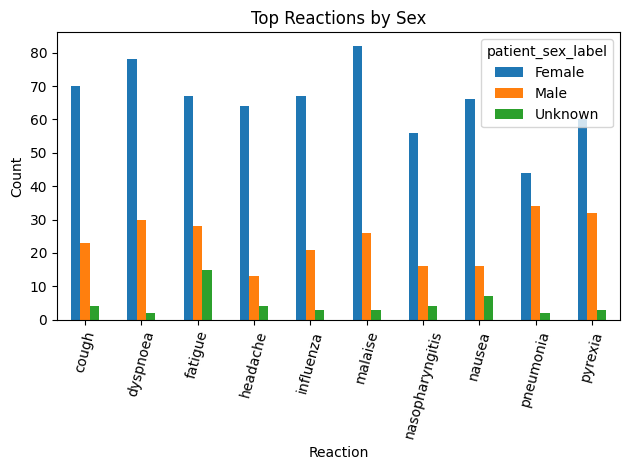

In [156]:
#Top reactions by Sex
top10_reactions = df["reaction"].value_counts().head(10).index
sex_reaction = (
    df[df["reaction"].isin(top10_reactions)]
    .groupby(["patient_sex_label", "reaction"])
    .size()
    .unstack(fill_value=0)
)

print("\nTop reactions by sex:")
display(sex_reaction)

if len(sex_reaction) > 0:
    sex_reaction.T.plot(kind="bar")
    plt.title("Top Reactions by Sex")
    plt.xlabel("Reaction")
    plt.ylabel("Count")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()


Age group vs Top reactions:


/tmp/ipykernel_218/4218184273.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_group", "reaction"])


reaction,cough,dyspnoea,fatigue,headache,influenza,malaise,nasopharyngitis,nausea,pneumonia,pyrexia
age_group,,,,,,,,,,
0-17,5,1,3,1,1,1,3,0,5,8
18-40,11,3,7,5,11,7,8,10,8,17
41-65,38,49,45,44,34,37,34,36,29,34
65+,29,37,27,19,19,42,23,25,28,24


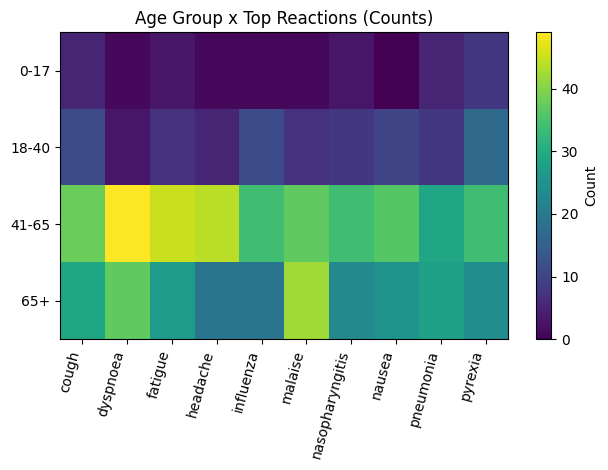

In [157]:
#Heatmap-style pivot (Age group x Top reactions)
top10_reactions = df["reaction"].value_counts().head(10).index

age_rx = (
    df[df["reaction"].isin(top10_reactions)]
    .groupby(["age_group", "reaction"])
    .size()
    .unstack(fill_value=0)
)

print("\nAge group vs Top reactions:")
display(age_rx)

#Simple heatmap using matplotlib
if len(age_rx) > 0:
    plt.imshow(age_rx.values, aspect="auto")
    plt.title("Age Group x Top Reactions (Counts)")
    plt.yticks(range(len(age_rx.index)), [str(x) for x in age_rx.index])
    plt.xticks(range(len(age_rx.columns)), age_rx.columns, rotation=75, ha="right")
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()


Top Unigrams:
pain               460
decreased          315
increased          246
blood              210
drug               209
disorder           191
infection          170
cough              138
dyspnoea           134
influenza          124
fatigue            112
malaise            111
respiratory        105
disease            102
weight             100
abnormal            98
pneumonia           97
abdominal           96
injection           95
pyrexia             95
tract               93
nausea              89
pulmonary           84
headache            84
swelling            80
syndrome            77
nasopharyngitis     76
skin                75
diarrhoea           73
rash                69
dtype: int64


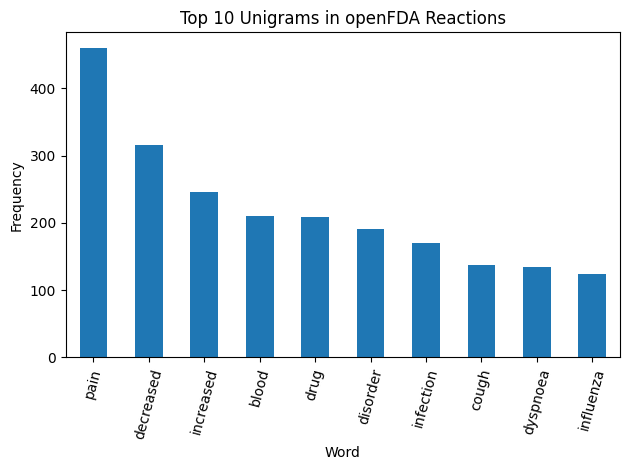


Top Bigrams (TRUE bigrams only):
tract infection          74
respiratory tract        61
abdominal pain           60
weight decreased         60
pain extremity           59
blood pressure           58
drug ineffective         53
drug hypersensitivity    45
oropharyngeal pain       40
decreased appetite       39
chest pain               36
weight increased         36
feeling abnormal         35
blood glucose            35
productive cough         33
dtype: int64


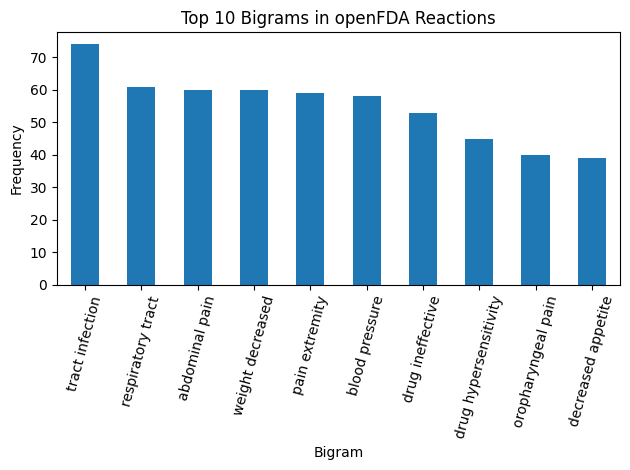

In [158]:
# Dataset-specific stopwords
domain_stop = {
    "site","use","product","count","label","off",
    "exposure","during","pregnancy","foetal"
}
custom_stopwords = list(ENGLISH_STOP_WORDS.union(domain_stop))

#N-gram analysis
#Unigrams
vectorizer_uni = CountVectorizer(
    ngram_range=(1,1),
    max_features=30,
    stop_words= custom_stopwords #Remove common stopwords to keep only meaningful terms
)
X_uni = vectorizer_uni.fit_transform(df["reaction"].fillna("").astype(str))
uni_counts = pd.Series(X_uni.sum(axis=0).A1, index=vectorizer_uni.get_feature_names_out()).sort_values(ascending=False)

print("\nTop Unigrams:")
print(uni_counts)

uni_counts.head(10).plot(kind="bar")
plt.title("Top 10 Unigrams in openFDA Reactions")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Bigrams only
vectorizer_bi = CountVectorizer(
    ngram_range=(2,2),
    max_features=20,
    stop_words= custom_stopwords # Remove common stopwords to keep only meaningful terms
)
X_bi = vectorizer_bi.fit_transform(df["reaction"].fillna("").astype(str))
bi_counts = pd.Series(X_bi.sum(axis=0).A1, index=vectorizer_bi.get_feature_names_out()).sort_values(ascending=False)

print("\nTop Bigrams (TRUE bigrams only):")
print(bi_counts.head(15))

bi_counts.head(10).plot(kind="bar")
plt.title("Top 10 Bigrams in openFDA Reactions")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


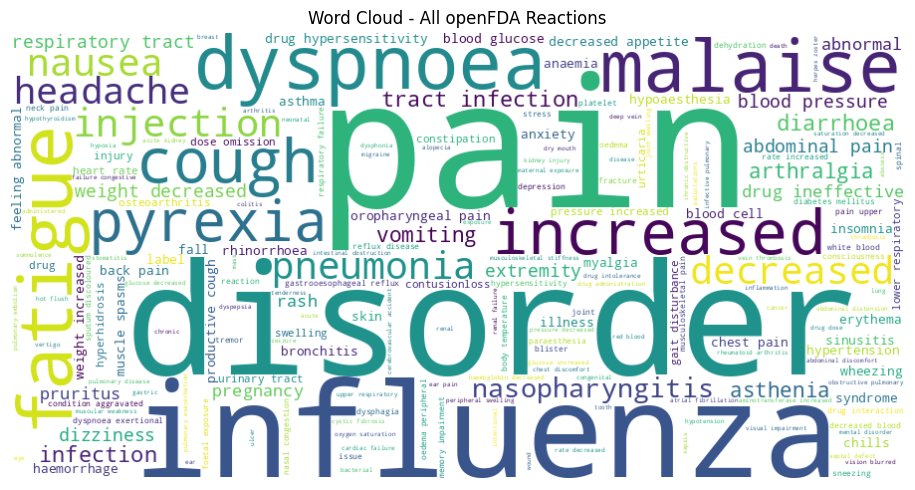

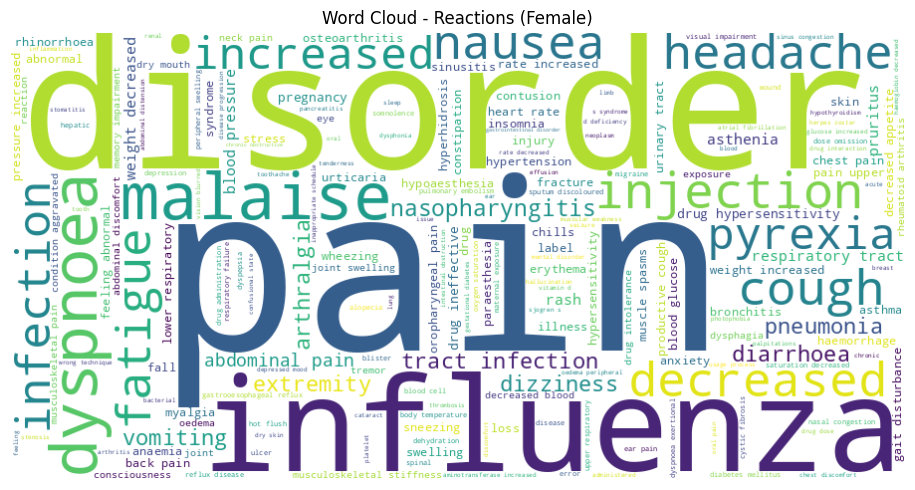

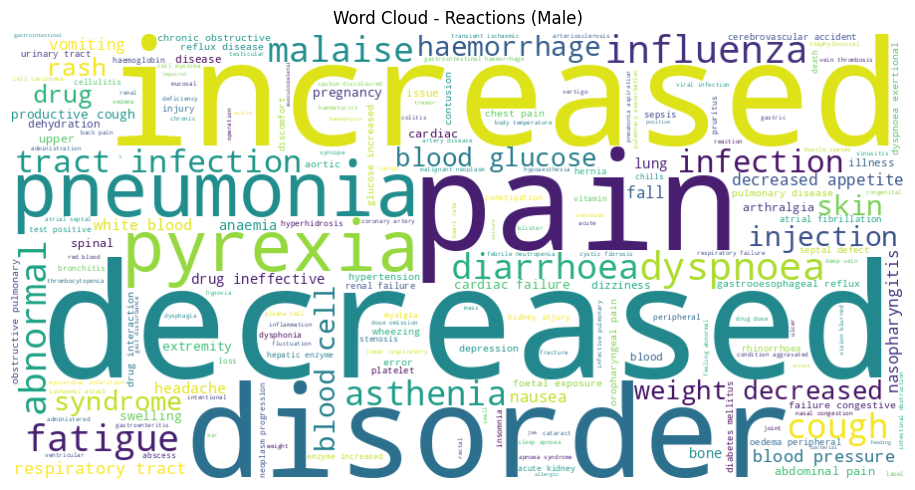

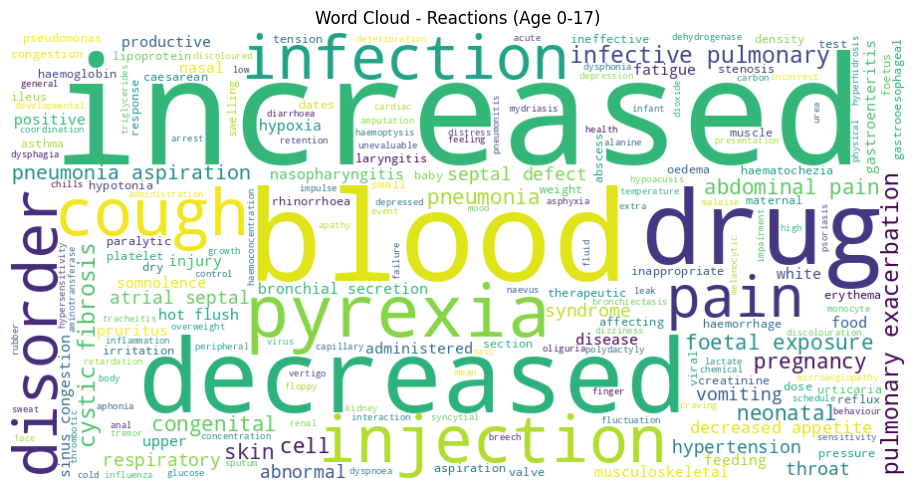

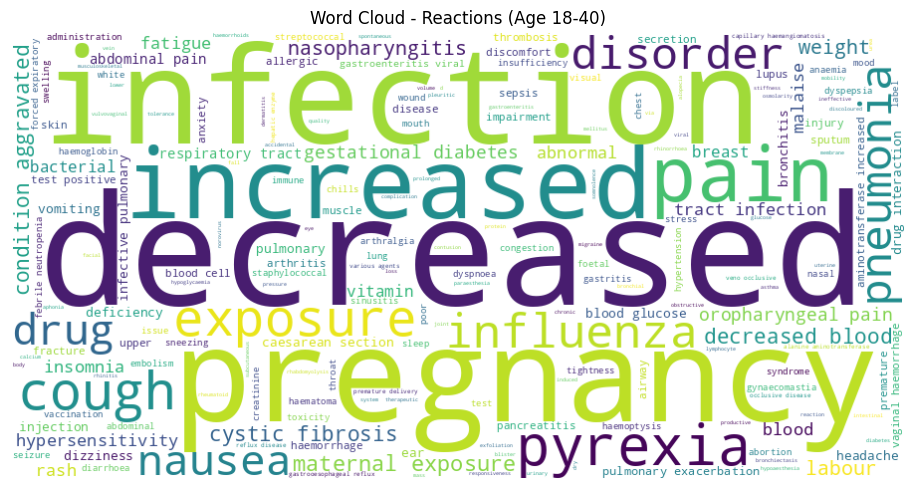

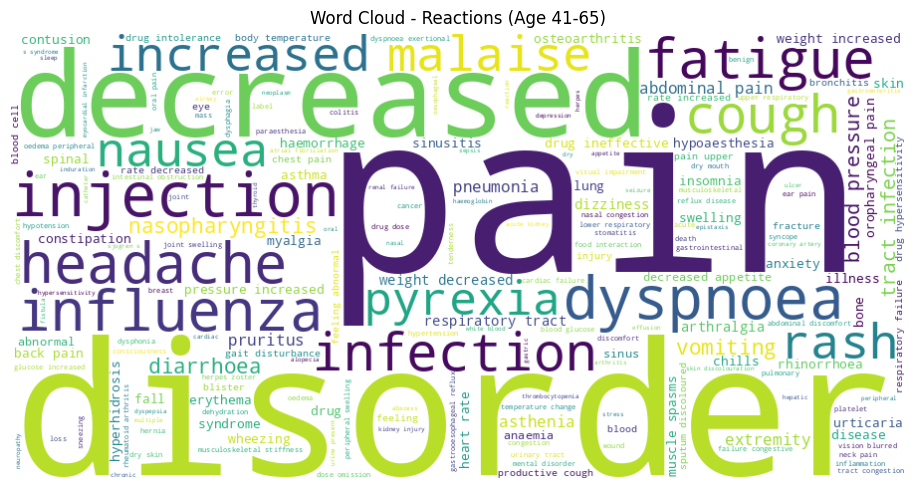

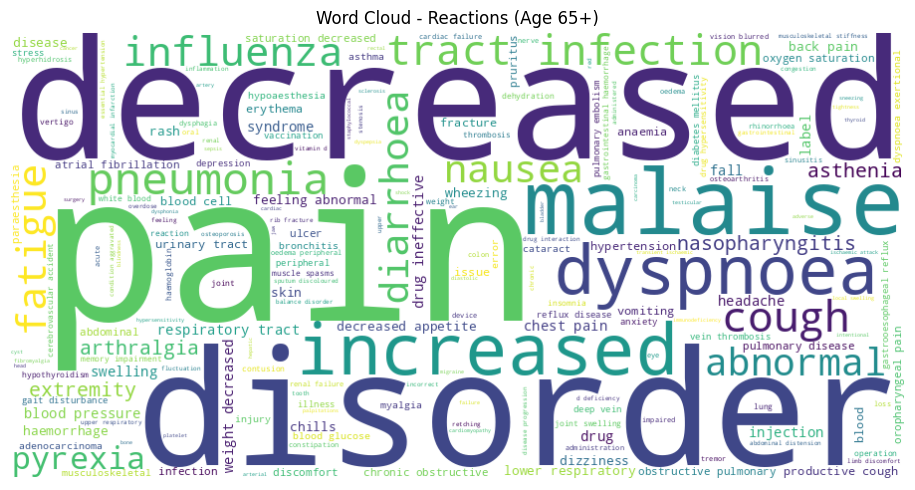

In [159]:
#Word clouds
def make_wordcloud(text, title):

    if not isinstance(text, str) or len(text.strip()) == 0:
        print("No text for wordcloud:", title)
        return

    #Add stopwords to remove common meaningless words
    extra_stopwords = STOPWORDS.union(["site", "use", "product", "count"])

    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        stopwords=extra_stopwords
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

#Overall
all_text = " ".join(df["reaction"].dropna().astype(str))
make_wordcloud(all_text, "Word Cloud - All openFDA Reactions")

#By Sex
for label in ["Female", "Male"]:
    subset = df[df["patient_sex_label"] == label]["reaction"].dropna().astype(str)
    make_wordcloud(" ".join(subset), f"Word Cloud - Reactions ({label})")

#By Age Group
for ag in ["0-17", "18-40", "41-65", "65+"]:
    subset = df[df["age_group"].astype(str) == ag]["reaction"].dropna().astype(str)
    make_wordcloud(" ".join(subset), f"Word Cloud - Reactions (Age {ag})")


In [160]:
#Topic modeling
docs = (
    df.groupby("report_id")["reaction"]
      .apply(lambda s: " ".join(s.dropna().astype(str)))
      .astype(str)
)

#Extend stopwords with dataset-specific terms
domain_stop = {
    "site","use","product","count","label","off",
    "exposure","during","pregnancy","foetal"
}
extra_stopwords = list(ENGLISH_STOP_WORDS.union(domain_stop))

#Use count vectorizer for LDA
lda_vectorizer = CountVectorizer(
    max_features=500,
    stop_words=extra_stopwords
)
X_docs = lda_vectorizer.fit_transform(docs)

n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X_docs)

terms = lda_vectorizer.get_feature_names_out()
print("\nTopics (LDA) from report-level documents:")
for topic_idx, topic in enumerate(lda.components_):
    top_terms_idx = topic.argsort()[::-1][:10]
    top_terms = [terms[i] for i in top_terms_idx]
    print(f"Topic {topic_idx+1}:", ", ".join(top_terms))



Topics (LDA) from report-level documents:
Topic 1: pain, infection, cough, disorder, malaise, respiratory, tract, influenza, pyrexia, fatigue
Topic 2: decreased, increased, blood, drug, dyspnoea, pressure, ineffective, weight, pulmonary, pain
Topic 3: pain, skin, failure, haemorrhage, disorder, drug, arthritis, renal, impairment, vomiting
Topic 4: syndrome, disease, pulmonary, atrial, thrombosis, chronic, pain, fracture, chest, peripheral
Topic 5: cell, increased, influenza, pneumonia, pain, blood, decreased, swelling, cancer, syndrome


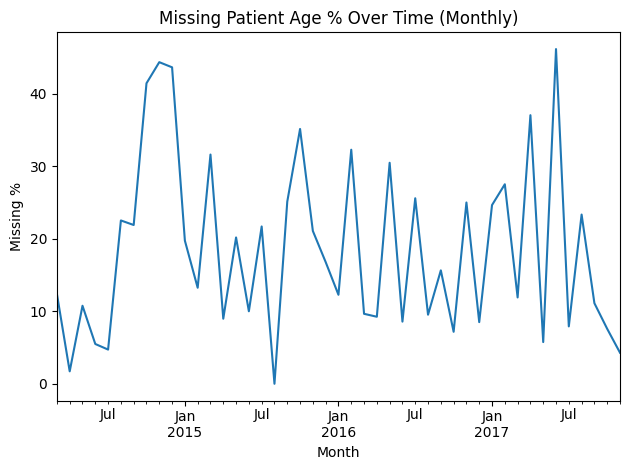

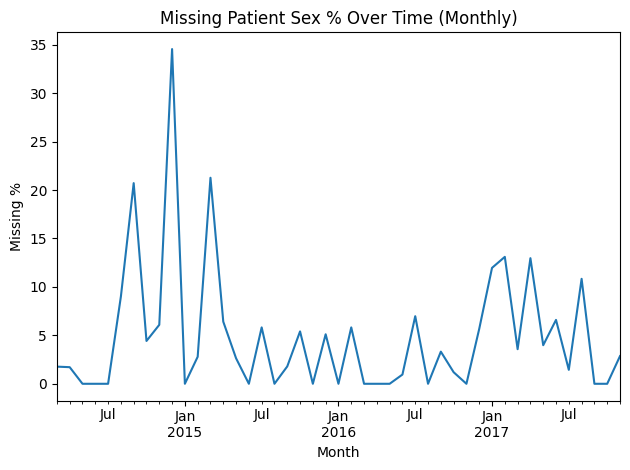

In [161]:
#missingness by time (age/sex missing over months)
df_time = df.dropna(subset=["report_date"]).copy()
df_time["month"] = df_time["report_date"].dt.to_period("M").dt.to_timestamp()

age_missing_by_month = df_time.groupby("month")["patient_age"].apply(lambda x: x.isna().mean() * 100)
sex_missing_by_month = df_time.groupby("month")["patient_sex"].apply(lambda x: x.isna().mean() * 100)

age_missing_by_month.plot()
plt.title("Missing Patient Age % Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()

sex_missing_by_month.plot()
plt.title("Missing Patient Sex % Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()